# Messaging Experiment: Estimating Treatment Effects at Scale
### Which message variant drives the most action, and for which users?

A real randomized field experiment (Gerber, Green & Larimer, 2008; 305,866 users),
analyzed with the methods used in product and marketing A/B testing.

Each message variant is treated as a campaign creative. The outcome `primary2006`
is the target action (conversion). `Control` is the holdout group that received no
message. The data is administrative, so covariates are limited to registration
fields (sex, year of birth, household size, prior behavior); income and ethnicity
were never collected.

## Executive summary

- The strongest social-pressure message, **Neighbors**, lifts the action rate by
  **8.1 percentage points** over control (95% CI [7.6, 8.7]), a 27% relative gain.
  It wins in every subgroup tested.
- The lift is largest among **already-active users** (+9.7 pp) and peaks in the
  **31-75 age range** (+11.3 pp for active users aged 31-45). Once segment size is
  factored in, the **46-60 group is the largest total opportunity**, while active
  users aged 31-45 are the **most efficient large segment**.
- The two milder messages produce small lifts and are **statistically flat for the
  youngest and oldest users**. At the age extremes, only the strong message works.
- The effect of social pressure **grows with prior engagement** for the strong
  message, but is flat for the gentle reminder.
- **Recommendation:** ship Neighbors, prioritizing active users aged 31-45. Treat
  the milder variants as not worth the spend.

## 1. Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Consistent palette across the project
PALETTE = {"Civic Duty": "#7FA8C9", "Hawthorne": "#2C5F88", "Neighbors": "#C9A14A"}

# Core test: two-proportion z-test.
# Pooled SE for the hypothesis test, unpooled SE for the confidence interval.
def two_prop_ztest(n1, x1, n2, x2):
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p2 - p1) / se_pool
    pval = 2 * (1 - stats.norm.cdf(abs(z)))
    se_unp = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    return {"rate_control": p1, "rate_treat": p2, "diff": p2 - p1, "z": z,
            "p_value": pval, "ci_low": (p2 - p1) - 1.96 * se_unp,
            "ci_high": (p2 - p1) + 1.96 * se_unp}

## 2. Data and preparation

In [2]:
df = pd.read_csv("data/social_pressure_experiment.csv")
df.head()

,sex,yearofbirth,primary2004,messages,primary2006,hhsize
0,male,1941,0,Civic Duty,0,2
1,female,1947,0,Civic Duty,0,2
2,male,1951,0,Hawthorne,1,3
3,female,1950,0,Hawthorne,1,3
4,female,1982,0,Hawthorne,1,3


In [3]:
# Structure, baseline conversion, group sizes, missing values
print("Rows:", f"{df.shape[0]:,}", "| Columns:", df.shape[1])
print()
print("Overall action rate:", f"{df['primary2006'].mean():.4f}")
print()
print("Users per message variant:")
print(df["messages"].value_counts())
print()
print("Missing values total:", df.isnull().sum().sum())

Rows: 305,866 | Columns: 6

Overall action rate: 0.3122

Users per message variant:
messages
Control       191243
Civic Duty     38218
Hawthorne      38204
Neighbors      38201
Name: count, dtype: int64

Missing values total: 0


**Feature engineering.** The data is clean, so this step is preparation, not
cleaning. We derive age, age bands, a prior-behavior label, and a simple
treated-vs-control flag.

In [4]:
EXPERIMENT_YEAR = 2006
df["age"] = EXPERIMENT_YEAR - df["yearofbirth"]
df["age_group"] = pd.cut(df["age"], bins=[17, 30, 45, 60, 75, 200],
                         labels=["18-30", "31-45", "46-60", "61-75", "76+"])
df["prior_voter"] = np.where(df["primary2004"] == 1, "Prior voter", "Not prior voter")
df["treated"] = np.where(df["messages"] == "Control", "Control", "Any message")
df.head()

,sex,yearofbirth,primary2004,messages,primary2006,hhsize,age,age_group,prior_voter,treated
0,male,1941,0,Civic Duty,0,2,65,61-75,Not prior voter,Any message
1,female,1947,0,Civic Duty,0,2,59,46-60,Not prior voter,Any message
2,male,1951,0,Hawthorne,1,3,55,46-60,Not prior voter,Any message
3,female,1950,0,Hawthorne,1,3,56,46-60,Not prior voter,Any message
4,female,1982,0,Hawthorne,1,3,24,18-30,Not prior voter,Any message


**Data quality.** The earliest birth year is 1900, producing 19 records with
age over 100. In administrative data, 1900 is a common default for an unknown birth
year. These 19 of 305,866 records do not affect results, so we keep them but
document the issue.

In [5]:
print("Age summary:")
print(df["age"].describe())
print()
print("Records with age over 100:", (df["age"] > 100).sum())
print("Earliest year of birth:", df["yearofbirth"].min())

Age summary:
count   305,866.0000
mean         49.7856
std          14.4533
min          20.0000
25%          41.0000
50%          50.0000
75%          59.0000
max         106.0000
Name: age, dtype: float64

Records with age over 100: 19
Earliest year of birth: 1900


## 3. Overall treatment effect

First, the observed lift per variant. Descriptive only, no test yet.

In [6]:
control_rate = df.loc[df["messages"] == "Control", "primary2006"].mean()
summary = (df.groupby("messages")["primary2006"]
             .agg(n="size", action_rate="mean").reset_index())
summary["lift_pp"] = (summary["action_rate"] - control_rate) * 100
summary["lift_pct"] = (summary["action_rate"] / control_rate - 1) * 100
print(summary.sort_values("action_rate", ascending=False).to_string(index=False))

  messages      n  action_rate  lift_pp  lift_pct
 Neighbors  38201       0.3779   8.1310   27.4105
 Hawthorne  38204       0.3224   2.5736    8.6760
Civic Duty  38218       0.3145   1.7899    6.0341
   Control 191243       0.2966   0.0000    0.0000


**Significance.** With this sample size almost any real effect is significant,
so effect size and the confidence interval matter more than the p-value alone.

In [7]:
# Control counts and the headline test: Control vs Neighbors
control = df[df["messages"] == "Control"]["primary2006"]
n_control, x_control = len(control), control.sum()
neighbors = df[df["messages"] == "Neighbors"]["primary2006"]
res = two_prop_ztest(n_control, x_control, len(neighbors), neighbors.sum())

print("HEADLINE A/B TEST: Control vs Neighbors")
print(f"Control rate:   {res['rate_control']:.4f}")
print(f"Neighbors rate: {res['rate_treat']:.4f}")
print(f"Lift:           {res['diff'] * 100:.2f} pp")
print(f"z-statistic:    {res['z']:.2f}")
print(f"p-value:        {res['p_value']:.3g}")
print(f"95% CI (pp):    [{res['ci_low'] * 100:.2f}, {res['ci_high'] * 100:.2f}]")

HEADLINE A/B TEST: Control vs Neighbors
Control rate:   0.2966
Neighbors rate: 0.3779
Lift:           8.13 pp
z-statistic:    31.37
p-value:        0
95% CI (pp):    [7.60, 8.66]


In [8]:
# All arms vs control, with a Bonferroni correction for three comparisons
arms = ["Civic Duty", "Hawthorne", "Neighbors"]
records = []
for arm in arms:
    a = df[df["messages"] == arm]["primary2006"]
    r = two_prop_ztest(n_control, x_control, len(a), a.sum())
    records.append({"arm": arm, "lift_pp": r["diff"] * 100,
                    "ci_low_pp": r["ci_low"] * 100, "ci_high_pp": r["ci_high"] * 100,
                    "z": r["z"], "p_raw": r["p_value"]})
results = pd.DataFrame(records)
results["p_bonferroni"] = np.minimum(results["p_raw"] * len(arms), 1.0)
results["significant_05"] = results["p_bonferroni"] < 0.05
print(results.sort_values("lift_pp", ascending=False).to_string(index=False))

       arm  lift_pp  ci_low_pp  ci_high_pp       z  p_raw  p_bonferroni  significant_05
 Neighbors   8.1310     7.6034      8.6586 31.3662 0.0000        0.0000            True
 Hawthorne   2.5736     2.0622      3.0851 10.0129 0.0000        0.0000            True
Civic Duty   1.7899     1.2814      2.2985  6.9736 0.0000        0.0000            True


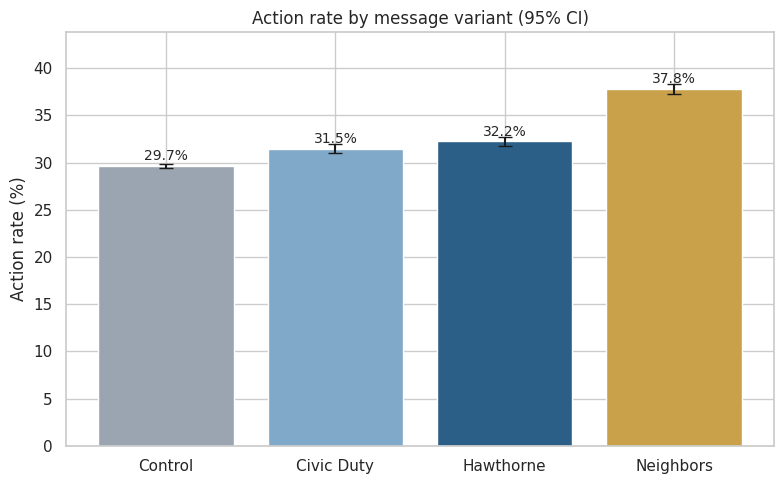

In [9]:
# Action rate by variant, with 95% confidence intervals
order = ["Control", "Civic Duty", "Hawthorne", "Neighbors"]
rates, errs = [], []
for arm in order:
    a = df[df["messages"] == arm]["primary2006"]
    p, n = a.mean(), len(a)
    rates.append(p * 100)
    errs.append(1.96 * np.sqrt(p * (1 - p) / n) * 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(order, rates, yerr=errs, capsize=5,
       color=["#9aa5b1", "#7FA8C9", "#2C5F88", "#C9A14A"], edgecolor="white")
for i, r in enumerate(rates):
    ax.text(i, r + 0.6, f"{r:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("Action rate (%)")
ax.set_title("Action rate by message variant (95% CI)")
ax.set_ylim(0, max(rates) + 6)
plt.tight_layout()
plt.show()

## 4. Who responds most: heterogeneous effects

The overall lift is an average. This section opens it up to find who responds best,
which turns the result into a targeting strategy.

### 4.1 By prior behavior and age

In [10]:
def subgroup_lift(data, group_col):
    rows = []
    for g, sub in data.groupby(group_col, observed=True):
        c = sub[sub["messages"] == "Control"]["primary2006"]
        t = sub[sub["messages"] == "Neighbors"]["primary2006"]
        r = two_prop_ztest(len(c), c.sum(), len(t), t.sum())
        rows.append({group_col: g, "control_pct": r["rate_control"] * 100,
                     "neighbors_pct": r["rate_treat"] * 100, "lift_pp": r["diff"] * 100,
                     "ci_low_pp": r["ci_low"] * 100, "ci_high_pp": r["ci_high"] * 100,
                     "z": r["z"]})
    return pd.DataFrame(rows)

print("Lift by prior behavior:")
print(subgroup_lift(df, "prior_voter").to_string(index=False))
print()
print("Lift by age group:")
print(subgroup_lift(df, "age_group").to_string(index=False))

Lift by prior behavior:


    prior_voter  control_pct  neighbors_pct  lift_pp  ci_low_pp  ci_high_pp       z
Not prior voter      23.7110        30.6406   6.9296     6.2809      7.5783 22.0586
    Prior voter      38.5805        48.2330   9.6525     8.7944     10.5106 22.3718

Lift by age group:
age_group  control_pct  neighbors_pct  lift_pp  ci_low_pp  ci_high_pp       z
    18-30      15.6271        19.3364   3.7092     2.4148      5.0037  5.9331
    31-45      26.7925        35.6174   8.8249     7.8102      9.8396 17.9070
    46-60      30.9573        39.0658   8.1085     7.2818      8.9351 19.8923
    61-75      38.9900        49.4034  10.4134     9.0806     11.7462 15.5178
      76+      33.5532        40.1557   6.6026     4.1276      9.0775  5.3515


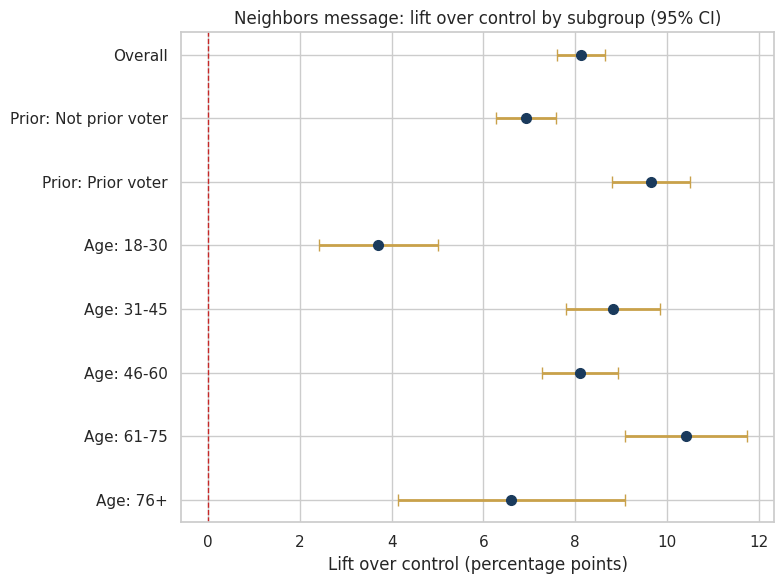

In [11]:
# Forest plot: Neighbors lift over control across subgroups
nb = df[df["messages"] == "Neighbors"]["primary2006"]
overall = two_prop_ztest(n_control, x_control, len(nb), nb.sum())
prior = subgroup_lift(df, "prior_voter")
age = subgroup_lift(df, "age_group")

labels = ["Overall"] + [f"Prior: {r}" for r in prior["prior_voter"]] + [f"Age: {r}" for r in age["age_group"]]
lifts = [overall["diff"] * 100] + list(prior["lift_pp"]) + list(age["lift_pp"])
lo = [overall["ci_low"] * 100] + list(prior["ci_low_pp"]) + list(age["ci_low_pp"])
hi = [overall["ci_high"] * 100] + list(prior["ci_high_pp"]) + list(age["ci_high_pp"])

y = np.arange(len(labels))[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(lifts, y, xerr=[np.array(lifts) - np.array(lo), np.array(hi) - np.array(lifts)],
            fmt="o", color="#1A3A5C", ecolor="#C9A14A", elinewidth=2, capsize=4, markersize=7)
ax.axvline(0, color="#C62828", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Lift over control (percentage points)")
ax.set_title("Neighbors message: lift over control by subgroup (95% CI)")
plt.tight_layout()
plt.show()

### 4.2 Age and prior behavior combined

Crossing the two dimensions reveals the single best target. The strongest cells are
active users aged 31-45 and 61-75. The weakest is young dormant users.

In [12]:
def cross_lift(data):
    rows = []
    for ag in ["18-30", "31-45", "46-60", "61-75", "76+"]:
        for pv in ["Not prior voter", "Prior voter"]:
            sub = data[(data["age_group"] == ag) & (data["prior_voter"] == pv)]
            c = sub[sub["messages"] == "Control"]["primary2006"]
            t = sub[sub["messages"] == "Neighbors"]["primary2006"]
            r = two_prop_ztest(len(c), c.sum(), len(t), t.sum())
            rows.append({"age_group": ag, "prior_voter": pv,
                         "n_neighbors": len(t), "lift_pp": r["diff"] * 100, "z": r["z"]})
    return pd.DataFrame(rows)

cross = cross_lift(df)
print("Smallest Neighbors cell:", cross["n_neighbors"].min())
lift_matrix = cross.pivot(index="age_group", columns="prior_voter", values="lift_pp")
print(lift_matrix.round(2))

Smallest Neighbors cell: 734
prior_voter  Not prior voter  Prior voter
age_group                                
18-30                 1.8200       6.6200
31-45                 6.4700      11.3200
46-60                 7.8200       8.5800
61-75                 9.7100      11.2600
76+                   4.7800       9.3800


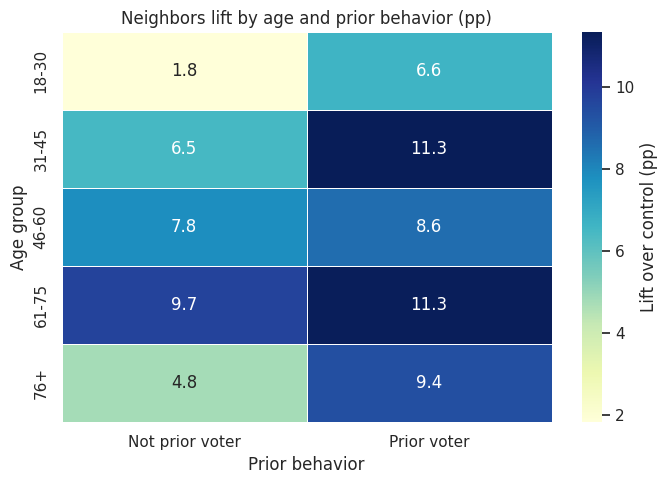

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(lift_matrix[["Not prior voter", "Prior voter"]], annot=True, fmt=".1f",
            cmap="YlGnBu", cbar_kws={"label": "Lift over control (pp)"},
            linewidths=0.5, ax=ax)
ax.set_title("Neighbors lift by age and prior behavior (pp)")
ax.set_xlabel("Prior behavior")
ax.set_ylabel("Age group")
plt.tight_layout()
plt.show()

### 4.3 Do the weaker messages behave differently?

Looking at all three variants across subgroups uncovers two patterns the
Neighbors-only view hides:

- At the age extremes (18-30 and 76+) the two milder messages are not significant.
  Only the strong message moves these users.
- The effect of the strong message grows with prior engagement, while the gentle
  reminder is flat across engagement.

In [14]:
def all_treatment_lifts(data, group_col):
    out = []
    for g, sub in data.groupby(group_col, observed=True):
        c = sub[sub["messages"] == "Control"]["primary2006"]
        for arm in ["Civic Duty", "Hawthorne", "Neighbors"]:
            t = sub[sub["messages"] == arm]["primary2006"]
            r = two_prop_ztest(len(c), c.sum(), len(t), t.sum())
            out.append({group_col: g, "treatment": arm, "lift_pp": r["diff"] * 100,
                        "z": r["z"], "significant": abs(r["z"]) > 1.96})
    return pd.DataFrame(out)

by_age = all_treatment_lifts(df, "age_group")
by_prior = all_treatment_lifts(df, "prior_voter")
print("By age group:")
print(by_age.to_string(index=False))
print()
print("By prior behavior:")
print(by_prior.to_string(index=False))

By age group:
age_group  treatment  lift_pp       z  significant
    18-30 Civic Duty   0.9886  1.6101        False
    18-30  Hawthorne   0.2036  0.3272        False
    18-30  Neighbors   3.7092  5.9331         True
    31-45 Civic Duty   2.5392  5.1904         True
    31-45  Hawthorne   2.8660  5.9120         True
    31-45  Neighbors   8.8249 17.9070         True
    46-60 Civic Duty   1.0146  2.5368         True
    46-60  Hawthorne   2.8742  7.1374         True
    46-60  Neighbors   8.1085 19.8923         True
    61-75 Civic Duty   3.4434  5.0954         True
    61-75  Hawthorne   3.0388  4.5151         True
    61-75  Neighbors  10.4134 15.5178         True
      76+ Civic Duty   2.0551  1.6304        False
      76+  Hawthorne   2.1485  1.7119        False
      76+  Neighbors   6.6026  5.3515         True

By prior behavior:
    prior_voter  treatment  lift_pp       z  significant
Not prior voter Civic Duty   1.8293  5.9219         True
Not prior voter  Hawthorne   2.3296 

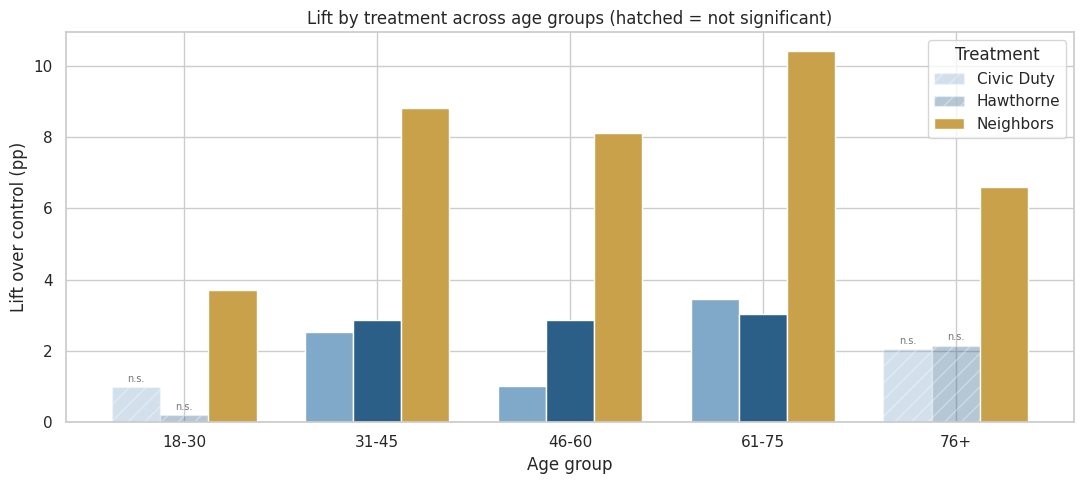

In [15]:
# Lift by treatment across age groups. Non-significant bars are hatched.
ages = ["18-30", "31-45", "46-60", "61-75", "76+"]
treatments = ["Civic Duty", "Hawthorne", "Neighbors"]
cell = {}
for ag in ages:
    sub = df[df["age_group"] == ag]
    c = sub[sub["messages"] == "Control"]["primary2006"]
    cell[ag] = {a: two_prop_ztest(len(c), c.sum(),
                                  len(sub[sub["messages"] == a]["primary2006"]),
                                  sub[sub["messages"] == a]["primary2006"].sum())
                for a in treatments}

fig, ax = plt.subplots(figsize=(11, 5))
w, x = 0.25, np.arange(len(ages))
for i, a in enumerate(treatments):
    vals = [cell[ag][a]["diff"] * 100 for ag in ages]
    bars = ax.bar(x + (i - 1) * w, vals, w, color=PALETTE[a], label=a, edgecolor="white")
    for b, ag in zip(bars, ages):
        if abs(cell[ag][a]["z"]) <= 1.96:
            b.set_alpha(0.35)
            b.set_hatch("//")
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.15,
                    "n.s.", ha="center", fontsize=7, color="#777777")
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(ages)
ax.set_xlabel("Age group"); ax.set_ylabel("Lift over control (pp)")
ax.set_title("Lift by treatment across age groups (hatched = not significant)")
ax.legend(title="Treatment")
plt.tight_layout()
plt.show()

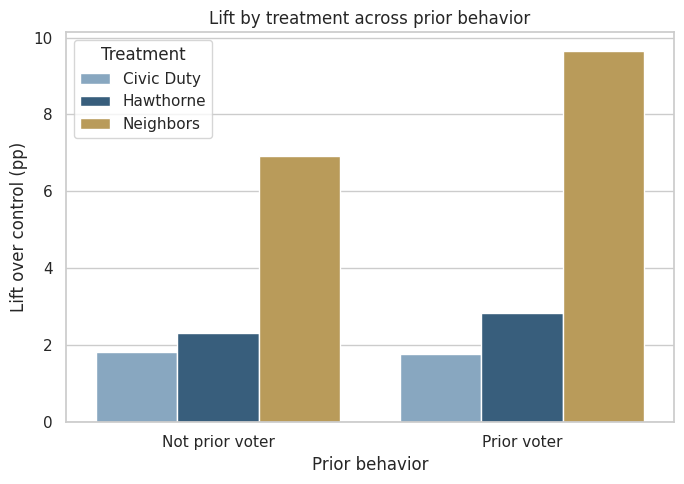

In [16]:
# Lift by treatment across prior behavior
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=by_prior, x="prior_voter", y="lift_pp", hue="treatment",
            palette=PALETTE, ax=ax)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_xlabel("Prior behavior"); ax.set_ylabel("Lift over control (pp)")
ax.set_title("Lift by treatment across prior behavior")
ax.legend(title="Treatment")
plt.tight_layout()
plt.show()

## 5. Business impact and recommendation

**Where is the opportunity?** This map plots each segment by lift (efficiency
per message) against size (reach). Bubble area is the incremental actions from
sending the message to that whole segment. Top-right is the prime target.

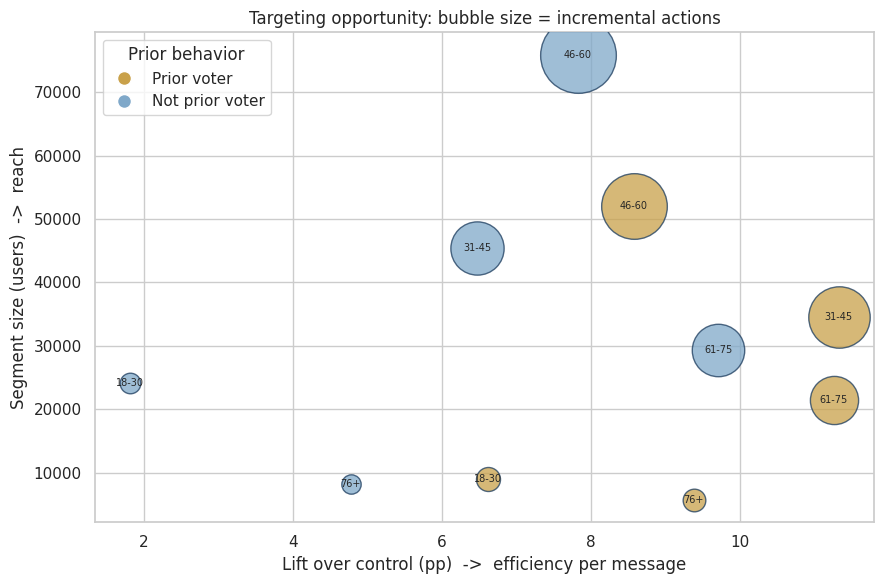

In [17]:
# Targeting opportunity: lift vs reach, bubble = incremental actions
opp = []
for ag in ["18-30", "31-45", "46-60", "61-75", "76+"]:
    for pv in ["Not prior voter", "Prior voter"]:
        sub = df[(df["age_group"] == ag) & (df["prior_voter"] == pv)]
        c = sub[sub["messages"] == "Control"]["primary2006"]
        t = sub[sub["messages"] == "Neighbors"]["primary2006"]
        r = two_prop_ztest(len(c), c.sum(), len(t), t.sum())
        opp.append({"age": ag, "prior": pv, "reach": len(sub), "lift_pp": r["diff"] * 100})
opp = pd.DataFrame(opp)
opp["incremental"] = opp["reach"] * opp["lift_pp"] / 100

from matplotlib.lines import Line2D
cmap = {"Prior voter": "#C9A14A", "Not prior voter": "#7FA8C9"}
fig, ax = plt.subplots(figsize=(9, 6))
for _, r in opp.iterrows():
    ax.scatter(r["lift_pp"], r["reach"], s=r["incremental"] * 0.5, c=cmap[r["prior"]],
               alpha=0.75, edgecolor="#1A3A5C", zorder=3)
    ax.annotate(r["age"], (r["lift_pp"], r["reach"]), fontsize=7, ha="center", va="center", zorder=4)
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap[k], markersize=10, label=k)
           for k in cmap]
ax.legend(handles=handles, title="Prior behavior", loc="upper left")
ax.set_xlabel("Lift over control (pp)  ->  efficiency per message")
ax.set_ylabel("Segment size (users)  ->  reach")
ax.set_title("Targeting opportunity: bubble size = incremental actions")
plt.tight_layout()
plt.show()

In [18]:
# Translate the measured lift into expected incremental actions (illustrative)
AUDIENCE = 100_000
COST_PER_MESSAGE = 0.10
impact = results[["arm", "lift_pp"]].copy()
impact["incremental_actions"] = AUDIENCE * impact["lift_pp"] / 100
impact["total_cost"] = AUDIENCE * COST_PER_MESSAGE
impact["cost_per_incremental_action"] = impact["total_cost"] / impact["incremental_actions"]
print(f"Illustrative rollout: {AUDIENCE:,} users per variant at {COST_PER_MESSAGE:.2f} per message")
print()
print(impact.sort_values("cost_per_incremental_action").to_string(index=False))

Illustrative rollout: 100,000 users per variant at 0.10 per message

       arm  lift_pp  incremental_actions  total_cost  cost_per_incremental_action
 Neighbors   8.1310           8,130.9913 10,000.0000                       1.2299
 Hawthorne   2.5736           2,573.6312 10,000.0000                       3.8856
Civic Duty   1.7899           1,789.9344 10,000.0000                       5.5868


### Findings and recommendation

**Result.** All three messages lift the action rate and all are significant, but
effect size separates them: Neighbors +8.1 pp, Hawthorne +2.6 pp, Civic Duty +1.8 pp.

**Who responds most.** The Neighbors lift is largest among already-active users
(+9.7 pp) and peaks in the 31-75 age range, reaching +11.3 pp for active users
aged 31-45.

**Efficiency vs volume.** Once segment size is included, the picture splits. Active
users aged 31-45 are the most efficient large segment, with the highest lift. The
46-60 group is the largest total opportunity, because its size outweighs a slightly
smaller lift. The right target depends on the goal: efficiency per message or total
volume.

**Two patterns the headline hides.** At the youngest and oldest ages, only the
strong message produces a significant lift. And the strong message amplifies with
prior engagement, while the gentle reminder is flat.

**Robustness.** Neighbors wins in every subgroup. The ranking never reverses.

**Recommendation.** Ship the Neighbors message. Under a limited budget, prioritize
active users aged 31-45 for efficiency. To maximize total incremental actions, lead
with the 46-60 segment. Avoid young dormant users, where both the lift and the
milder messages fall flat. The milder variants are significant but small, and
likely not worth the spend.

**Caveats.** The data is administrative, so covariates are limited. A real
social-pressure message also carries privacy and trust considerations that sit
outside this analysis.